In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

from chemap import metrics
from chemap.fingerprint_computation import compute_fingerprints, FingerprintConfig
from chemap.fingerprint_conversions import fingerprints_to_csr

# import fingerprint algorithms
from rdkit.Chem import rdFingerprintGenerator
from skfp.fingerprints import (
    MACCSFingerprint, 
    PubChemFingerprint,
    KlekotaRothFingerprint,
    AvalonFingerprint,
)
from chemap.fingerprints import MAP4FPGen, LingoFingerprint

In [2]:
path_data = r"/home/daisy/Florian/fingerprint_research/NP_Fingerprints/Data"

In [3]:
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence

import numpy as np
import scipy.sparse as sp
from joblib import Parallel, delayed
from sklearn.base import BaseEstimator, TransformerMixin

from biosynfoni import Biosynfoni


class BiosynfoniTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-style wrapper around Biosynfoni.

    Inputs to fit/transform: Sequence[rdkit.Chem.Mol]
    Output:
      - variant="folded": (N, D) dense float32 or CSR float32 (if sparse=True)
      - variant="raw_bits": same as above; chemap will convert to unfolded if cfg.folded=False
        (for Biosynfoni, raw feature space is already 0..D-1, so "raw_bits" == "folded")
    """

    def __init__(
        self,
        *,
        sparse: bool = False,
        variant: str = "folded",   # chemap may set this to "raw_bits"
        n_jobs: int = 1,
        verbose: int = 0,
    ):
        self.sparse = sparse
        self.variant = variant
        self.n_jobs = n_jobs
        self.verbose = verbose

    def fit(self, X: Sequence[Any], y: Any = None) -> "BiosynfoniTransformer":
        # No training needed, but sklearn expects fit() to exist.
        return self

    def transform(self, X: Sequence[Any]):
        # X is expected to be a list of RDKit mols (some may be None depending on your mol pipeline)
        def fp_row(mol) -> np.ndarray:
            if mol is None:
                # let chemap decide what to do with invalids; here we return empty and let caller handle
                return np.array([], dtype=np.float32)
            arr = np.asarray(Biosynfoni(mol).fingerprint, dtype=np.float32)
            return arr

        rows: List[np.ndarray] = Parallel(n_jobs=self.n_jobs)(
            delayed(fp_row)(mol) for mol in X
        )

        # Infer D from first non-empty row
        D = next((r.shape[0] for r in rows if r.size), 0)

        # Backfill empties to keep rectangular output (chemap currently passes only valid mols,
        # but this also makes the transformer robust if you change that later)
        for i, r in enumerate(rows):
            if r.size == 0 and D:
                rows[i] = np.zeros((D,), dtype=np.float32)

        X_dense = np.vstack(rows).astype(np.float32, copy=False) if rows else np.zeros((0, D), dtype=np.float32)

        if not self.sparse:
            return X_dense

        return sp.csr_matrix(X_dense, dtype=np.float32)


In [4]:
data = pd.read_csv(os.path.join(path_data, "cmnpd.csv"))
data = data.drop("Unnamed: 0", axis=1)
data

,COMPOUND_ID,SMILES,BIOACTIVITY_IN_BRIEF
0,CMNPD1,C1SCSS1,antibiotic
1,CMNPD2,[O-][S+]1CSSC1,antibiotic
2,CMNPD3,[O-][S+]1CSCS1,antibiotic
3,CMNPD4,C1SSCSSS1,antibiotic
4,CMNPD5,C1SCSSCS1,antibiotic
...,...,...,...
31556,CMNPD31557,C[C@@H](C/C=C/C(C)(C)O)[C@@H]1CC[C@]2(C)C3=CC(...,NaN
31557,CMNPD31558,C[C@@H](CCC(=O)O)[C@@H]1CC[C@]2(C)C3=CC[C@H]4C...,FXR agonist
31558,CMNPD31559,CC(=O)O[C@@H]1C[C@H]2C(C)(C)C(=O)C=C[C@]2(C)[C...,PXR agonist
31559,CMNPD31560,CC1(C)CCC2=C(C1)[C@]1(C)CC[C@@H]3[C@@]4(C)C[C@...,NaN


In [5]:
data.value_counts("BIOACTIVITY_IN_BRIEF").head(20)

BIOACTIVITY_IN_BRIEF
cytotoxic                 1219
antimicrobial              219
mildly cytotoxic           212
cytotoxicity               132
antifungal                 127
moderately cytotoxic        97
ichthyotoxic                68
antibacterial               66
cytotoxin                   59
moderate cytotoxicity       55
toxin                       49
mild cytotoxicity           48
anti-inflammatory           40
toxic to brine shrimp       40
toxic                       37
antitumour                  35
No inhib. NO prod.          33
cytotoxic | antifungal      32
weakly cytotoxic            31
antibiotic                  31
Name: count, dtype: int64

In [6]:
props = ['kinase_c',
 'antimalarial',
 'antibiotic',
 'phosphatase',
 'antifungal',
 'anti-inflammatory',
 'atpase',
 'leishmanial',
 'serine_protease',
 'hiv',
 'antiviral',
 'antitumour']

In [7]:
text_col = "BIOACTIVITY_IN_BRIEF"
bio = data[text_col].fillna("").astype(str)
df_props = data.copy()

for prop_name in props:
    df_props[prop_name] = bio.str.contains(prop_name, case=False, regex=False).astype(np.int8)

df_props.head()

,COMPOUND_ID,SMILES,BIOACTIVITY_IN_BRIEF,kinase_c,antimalarial,antibiotic,phosphatase,antifungal,anti-inflammatory,atpase,leishmanial,serine_protease,hiv,antiviral,antitumour
0,CMNPD1,C1SCSS1,antibiotic,0,0,1,0,0,0,0,0,0,0,0,0
1,CMNPD2,[O-][S+]1CSSC1,antibiotic,0,0,1,0,0,0,0,0,0,0,0,0
2,CMNPD3,[O-][S+]1CSCS1,antibiotic,0,0,1,0,0,0,0,0,0,0,0,0
3,CMNPD4,C1SSCSSS1,antibiotic,0,0,1,0,0,0,0,0,0,0,0,0
4,CMNPD5,C1SCSSCS1,antibiotic,0,0,1,0,0,0,0,0,0,0,0,0


In [8]:
df_props.iloc[:, 3:].sum()  # check: same as in Boldini et al 2024

kinase_c              22
antimalarial          92
antibiotic           112
phosphatase           95
antifungal           364
anti-inflammatory    156
atpase                78
leishmanial           20
serine_protease       29
hiv                  178
antiviral            106
antitumour           154
dtype: int64

In [9]:
prop_cols = props

# all rows with at least one positive label
mask_pos = df_props[prop_cols].any(axis=1)
df_pos = df_props[mask_pos]

# Random sample (no duplicates) from all-zero rows, same size as df_pos
df_neg_pool = df_props[~mask_pos]
n = min(len(df_pos), len(df_neg_pool))  # in case there aren't enough negatives

df_neg = df_neg_pool.sample(n=n, replace=False, random_state=42)

# 3) combine + (optional) shuffle
df_subset = (
    pd.concat([df_pos, df_neg], axis=0)
      .sample(frac=1.0, random_state=42)  # shuffle rows
      .reset_index(drop=True)
)
df_subset

,COMPOUND_ID,SMILES,BIOACTIVITY_IN_BRIEF,kinase_c,antimalarial,antibiotic,phosphatase,antifungal,anti-inflammatory,atpase,leishmanial,serine_protease,hiv,antiviral,antitumour
0,CMNPD21740,CC(=O)O[C@H]1[C@H]2[C@@H](C[C@@H](O)[C@@]3(O)C...,antiviral activity (human cytomegalovirus),0,0,0,0,0,0,0,0,0,0,1,0
1,CMNPD15235,CC(C)C[C@H](O)C[C@@H](C)[C@H]1CC=C2C3=C(CC[C@@...,NaN,0,0,0,0,0,0,0,0,0,0,0,0
2,CMNPD19097,C/C1=C\[C@H](C)C[C@H](C)OC(=O)C[C@H](c2ccc(O)c...,cytotoxic,0,0,0,0,0,0,0,0,0,0,0,0
3,CMNPD13217,CC(Cl)C(O)C1=C[C@@H]([C@H](C)O)OC1=O,antibiotics,0,0,1,0,0,0,0,0,0,0,0,0
4,CMNPD4551,COc1c(OC)c(S(C)=S)c2c(c1N(C)C)CCSC2OC,antifungal,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,CMNPD11938,C[C@H]1CCCCCCCNCCCNC1,NaN,0,0,0,0,0,0,0,0,0,0,0,0
2676,CMNPD22463,CCCCC(C)C/C(=C/[C@@]1(CC)OC(=O)C[C@@H]1O)CC,antifungal,0,0,0,0,1,0,0,0,0,0,0,0
2677,CMNPD23467,COc1cc(/C=C/c2ccccc2)oc(=O)c1C,inhibitor of protein tyrosine phosphatase 1B (...,0,0,0,1,0,0,0,0,0,0,0,0
2678,CMNPD29818,O=C(NCCc1ccccc1)NCCc1ccccc1C(=O)NCCc1ccccc1C(=...,weak anti-HIV | no AB activ.,0,0,0,0,0,0,0,0,0,1,0,0


# Try deep learning based prediction from fingerprints as task
- Issue 1: for some labels we have *very few* cases (e.g., 20)
- Multi-label and rare classes make it difficult to simply apply cross-folds or other techniques

--> Let's train multi-label classifier models on several random splits

In [22]:
# ------------------------
# Define experiments
# ------------------------
invgen = rdFingerprintGenerator.GetMorganFeatureAtomInvGen()  # == useFeatures=True
    
FP_SIZE = 4096  # for all fingerprints with variable bit sizes

experiments = [
    # --- Morgan / ECFP (RDKit generators) ---
    #("morgan2_count",  rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_SIZE), True),
    #("morgan2_binary", rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_SIZE), False),
    ("morgan3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), True),
    ("morgan3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE), False),
    ("morgan9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), True),
    ("morgan9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE), False),
    ("fcfp3_count",  rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp9_count", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), True),
    ("fcfp3_binary", rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    ("fcfp9_binary", rdFingerprintGenerator.GetMorganGenerator(radius=9, fpSize=FP_SIZE, atomInvariantsGenerator=invgen), False),
    
    # --- path-based fingerprint (RDKitFP) ---
    ("rdkit_count", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), True),
    ("rdkit_binary", rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=FP_SIZE), False),
    ("avalon_binary", AvalonFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("avalon_count", AvalonFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),

    # --- Complementary classic hashed fingerprints via RDKit generators ---
    # Atom Pair + Topological Torsion are standard alternatives to circular fingerprints
    ("atompair_binary", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=FP_SIZE), False),
    ("atompair_count", rdFingerprintGenerator.GetAtomPairGenerator(fpSize=FP_SIZE), True),
    ("ttorsion_binary", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=FP_SIZE), False),
    ("ttorsion_count", rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=FP_SIZE), True),

    # String based
    ("lingo_binary", LingoFingerprint(fp_size=FP_SIZE, count=False, sparse=False), False),
    ("lingo_count", LingoFingerprint(fp_size=FP_SIZE, count=True, sparse=False), True),    
    
    # map4 (from scikit-fingerprints)
    ("map4_binary", MAP4FPGen(dimensions=FP_SIZE, radius=2), False),
    ("map4_count", MAP4FPGen(dimensions=FP_SIZE, radius=2), True),
    
    # defined feature fingerprints
    ("maccs_binary", MACCSFingerprint(count=False, sparse=False), False),
    ("maccs_count", MACCSFingerprint(count=True, sparse=False), True),
    ("pubchem_binary", PubChemFingerprint(count=False, sparse=False), False),
    ("pubchem_count", PubChemFingerprint(count=True, sparse=False), True),
    ("klekotaroth_binary", KlekotaRothFingerprint(count=False, sparse=False), False),
    ("klekotaroth_count", KlekotaRothFingerprint(count=True, sparse=False), True),
    ("biosynfoni_count", BiosynfoniTransformer(sparse=False, n_jobs=-1), True),
]

In [12]:
df_subset

,COMPOUND_ID,SMILES,BIOACTIVITY_IN_BRIEF,kinase_c,antimalarial,antibiotic,phosphatase,antifungal,anti-inflammatory,atpase,leishmanial,serine_protease,hiv,antiviral,antitumour
0,CMNPD21740,CC(=O)O[C@H]1[C@H]2[C@@H](C[C@@H](O)[C@@]3(O)C...,antiviral activity (human cytomegalovirus),0,0,0,0,0,0,0,0,0,0,1,0
1,CMNPD15235,CC(C)C[C@H](O)C[C@@H](C)[C@H]1CC=C2C3=C(CC[C@@...,NaN,0,0,0,0,0,0,0,0,0,0,0,0
2,CMNPD19097,C/C1=C\[C@H](C)C[C@H](C)OC(=O)C[C@H](c2ccc(O)c...,cytotoxic,0,0,0,0,0,0,0,0,0,0,0,0
3,CMNPD13217,CC(Cl)C(O)C1=C[C@@H]([C@H](C)O)OC1=O,antibiotics,0,0,1,0,0,0,0,0,0,0,0,0
4,CMNPD4551,COc1c(OC)c(S(C)=S)c2c(c1N(C)C)CCSC2OC,antifungal,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,CMNPD11938,C[C@H]1CCCCCCCNCCCNC1,NaN,0,0,0,0,0,0,0,0,0,0,0,0
2676,CMNPD22463,CCCCC(C)C/C(=C/[C@@]1(CC)OC(=O)C[C@@H]1O)CC,antifungal,0,0,0,0,1,0,0,0,0,0,0,0
2677,CMNPD23467,COc1cc(/C=C/c2ccccc2)oc(=O)c1C,inhibitor of protein tyrosine phosphatase 1B (...,0,0,0,1,0,0,0,0,0,0,0,0
2678,CMNPD29818,O=C(NCCc1ccccc1)NCCc1ccccc1C(=O)NCCc1ccccc1C(=...,weak anti-HIV | no AB activ.,0,0,0,0,0,0,0,0,0,1,0,0


In [13]:
df_subset.to_csv("activity_prediction_dataset.csv", index=False)

# Try with small hyperparameter search (grid search) + k-folds!

In [24]:
# ------------------------
# Grid search per fingerprint (ONLY lr, batch_size, weight_decay)
# - Uses ONE fixed tuning split (same split for every fingerprint) to reduce chance effects
# - Objective: macro_auc on the tuning validation set (fallback: micro_f1 if macro_auc is nan)
# - Then runs FINAL evaluation with n_splits random splits using the best grid params
#
# Leaves hidden_dim + dropout fixed (global constants).
# ------------------------

import os
import json
import time
import random
from typing import Dict, Any, Tuple, Optional, List

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, balanced_accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ------------------------
# Reproducibility
# ------------------------
SEED = 54321
def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------
# Dataset / Model
# ------------------------
class NumpyMultiLabelDataset(Dataset):
    def __init__(self, X: np.ndarray, Y: np.ndarray):
        assert X.shape[0] == Y.shape[0]
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.Y[idx])


class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x


def _apply_fp_transform(X: np.ndarray, *, count_fp: bool) -> np.ndarray:
    if count_fp:
        X = np.log1p(X)
    return X.astype(np.float32, copy=False)


@torch.no_grad()
def predict_logits(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_logits, all_y = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True).float()
        yb = yb.to(device, non_blocking=True).float()
        logits = model(xb)
        all_logits.append(logits.detach().cpu())
        all_y.append(yb.detach().cpu())
    return torch.cat(all_logits, 0).numpy(), torch.cat(all_y, 0).numpy()


def multilabel_metrics(
    y_true: np.ndarray,
    y_score: np.ndarray,
    threshold: float = 0.5,
    label_names: Optional[List[str]] = None,
) -> Dict[str, Any]:
    y_pred = (y_score >= threshold).astype(np.int32)

    subset_acc = float((y_pred == y_true).all(axis=1).mean())

    L = y_true.shape[1]
    per_label_acc, per_label_bal_acc, per_label_auc = [], [], []
    per_label_support_pos = y_true.sum(axis=0).astype(int).tolist()

    for j in range(L):
        yt = y_true[:, j].astype(int)
        yp = y_pred[:, j].astype(int)
        per_label_acc.append(float(accuracy_score(yt, yp)))

        if len(np.unique(yt)) == 2:
            per_label_bal_acc.append(float(balanced_accuracy_score(yt, yp)))
            per_label_auc.append(float(roc_auc_score(yt, y_score[:, j])))
        else:
            per_label_bal_acc.append(np.nan)
            per_label_auc.append(np.nan)

    micro_f1 = float(f1_score(y_true, y_pred, average="micro", zero_division=0))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    weighted_f1 = float(f1_score(y_true, y_pred, average="weighted", zero_division=0))

    try:
        micro_auc = float(roc_auc_score(y_true.ravel(), y_score.ravel()))
    except ValueError:
        micro_auc = float("nan")

    per_label_auc_arr = np.array(per_label_auc, dtype=float)
    macro_auc = float(np.nanmean(per_label_auc_arr)) if np.isfinite(per_label_auc_arr).any() else float("nan")

    per_label_bal_arr = np.array(per_label_bal_acc, dtype=float)
    mean_bal_acc = float(np.nanmean(per_label_bal_arr)) if np.isfinite(per_label_bal_arr).any() else float("nan")

    mean_acc = float(np.mean(per_label_acc)) if len(per_label_acc) else float("nan")

    if label_names is None:
        label_names = [f"label_{i}" for i in range(L)]

    per_label = pd.DataFrame({
        "label": label_names,
        "support_pos": per_label_support_pos,
        "accuracy": per_label_acc,
        "balanced_accuracy": per_label_bal_acc,
        "auc_roc": per_label_auc,
    })

    return {
        "threshold": float(threshold),
        "subset_accuracy": subset_acc,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "micro_auc": micro_auc,
        "macro_auc": macro_auc,
        "mean_label_accuracy": mean_acc,
        "mean_label_balanced_accuracy": mean_bal_acc,
        "per_label": per_label,
    }


def train_one_run_multilabel(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    X_val: np.ndarray,
    Y_val: np.ndarray,
    *,
    hidden_dim: int,
    dropout: float,
    batch_size: int,
    lr: float,
    weight_decay: float,
    max_epochs: int,
    patience: int,
    grad_clip_norm: float = 1.0,
    use_amp: bool = True,
    pos_weight: Optional[np.ndarray] = None,
    threshold: float = 0.5,
    label_names: Optional[List[str]] = None,
) -> Tuple[nn.Module, Dict[str, Any], Dict[str, Any]]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = DataLoader(
        NumpyMultiLabelDataset(X_train, Y_train),
        batch_size=batch_size, shuffle=True, num_workers=2,
        pin_memory=torch.cuda.is_available(), drop_last=False
    )
    val_loader = DataLoader(
        NumpyMultiLabelDataset(X_val, Y_val),
        batch_size=batch_size, shuffle=False, num_workers=2,
        pin_memory=torch.cuda.is_available(), drop_last=False
    )

    input_dim = X_train.shape[1]
    n_labels = Y_train.shape[1]
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=n_labels, dropout=dropout).to(device)

    pw = torch.tensor(pos_weight, dtype=torch.float32, device=device) if pos_weight is not None else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    best_state = None
    best_score = -np.inf
    bad_epochs = 0
    history = {"train_loss": [], "val_macro_auc": [], "val_micro_f1": []}
    best_val_metrics = None

    for epoch in range(1, max_epochs + 1):
        model.train()
        running = 0.0
        n_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True).float()
            yb = yb.to(device, non_blocking=True).float()

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=(use_amp and device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            if grad_clip_norm and grad_clip_norm > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

            scaler.step(optimizer)
            scaler.update()

            running += float(loss.item()) * xb.shape[0]
            n_seen += xb.shape[0]

        train_loss = running / max(n_seen, 1)

        val_logits, val_true = predict_logits(model, val_loader, device=device)
        val_score = 1.0 / (1.0 + np.exp(-val_logits))
        val_m = multilabel_metrics(val_true, val_score, threshold=threshold, label_names=label_names)

        score = val_m["macro_auc"]
        if not np.isfinite(score):
            score = val_m["micro_f1"]

        scheduler.step(score)

        history["train_loss"].append(float(train_loss))
        history["val_macro_auc"].append(float(val_m["macro_auc"]))
        history["val_micro_f1"].append(float(val_m["micro_f1"]))

        if score > best_score + 1e-6:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_metrics = val_m
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_summary = {
        "device": str(device),
        "best_val_score": float(best_score),
        "epochs_ran": len(history["train_loss"]),
        "history": history,
    }
    return model, train_summary, (best_val_metrics if best_val_metrics is not None else {})


# ------------------------
# Fixed tuning split indices (created ONCE, reused for all fingerprints)
# ------------------------
def make_fixed_tuning_split(
    Y: np.ndarray,
    *,
    seed: int,
    test_size: float = 0.20,
    val_size: float = 0.15,
) -> Dict[str, np.ndarray]:
    """
    Returns indices: train_idx, val_idx, holdout_idx (holdout unused for tuning objective, but kept)
    """
    label_count = Y.sum(axis=1).astype(int)
    strat_key = np.minimum(label_count, 3)

    idx_all = np.arange(len(Y))
    idx_trainval, idx_holdout = train_test_split(
        idx_all, test_size=test_size, random_state=seed, stratify=strat_key
    )

    Y_trainval = Y[idx_trainval]
    strat_key_tv = np.minimum(Y_trainval.sum(axis=1).astype(int), 3)

    idx_train, idx_val = train_test_split(
        idx_trainval, test_size=val_size, random_state=seed, stratify=strat_key_tv
    )

    return {"train_idx": idx_train, "val_idx": idx_val, "holdout_idx": idx_holdout}


# ------------------------
# Grid search (per fingerprint)
# ------------------------
def grid_search_for_fingerprint(
    *,
    fingerprints: np.ndarray,
    Y: np.ndarray,
    label_names: List[str],
    count_fp: bool,
    tuning_split: Dict[str, np.ndarray],
    grid: Dict[str, List[Any]],
    seed: int = SEED,
    # fixed architecture
    hidden_dim: int = 3000,
    dropout: float = 0.2,
    threshold: float = 0.5,
    # tuning training budget
    max_epochs_tune: int = 30,
    patience_tune: int = 6,
) -> Dict[str, Any]:
    """
    Exhaustive grid search on a fixed tuning split.
    Returns: best params + full grid table.
    """
    train_idx = tuning_split["train_idx"]
    val_idx = tuning_split["val_idx"]

    X_train = _apply_fp_transform(fingerprints[train_idx], count_fp=count_fp)
    Y_train = Y[train_idx].astype(np.float32, copy=False)
    X_val = _apply_fp_transform(fingerprints[val_idx], count_fp=count_fp)
    Y_val = Y[val_idx].astype(np.float32, copy=False)

    # pos_weight from TRAIN only
    pos = Y_train.sum(axis=0).astype(np.float64)
    neg = (Y_train.shape[0] - pos).astype(np.float64)
    pos_weight = (neg / np.maximum(pos, 1.0)).astype(np.float32)

    rows = []
    best = {"score": -np.inf, "params": None, "val_metrics": None}

    lrs = grid["lr"]
    bss = grid["batch_size"]
    wds = grid["weight_decay"]

    trial = 0
    for lr in lrs:
        for bs in bss:
            for wd in wds:
                trial += 1
                seed_everything(seed + trial)

                _, train_summary, val_m = train_one_run_multilabel(
                    X_train, Y_train, X_val, Y_val,
                    hidden_dim=hidden_dim,
                    dropout=dropout,
                    batch_size=int(bs),
                    lr=float(lr),
                    weight_decay=float(wd),
                    max_epochs=max_epochs_tune,
                    patience=patience_tune,
                    pos_weight=pos_weight,
                    threshold=threshold,
                    label_names=label_names,
                )

                score = val_m.get("macro_auc", float("nan"))
                if not np.isfinite(score):
                    score = val_m.get("micro_f1", -np.inf)

                row = {
                    "trial": trial,
                    "lr": float(lr),
                    "batch_size": int(bs),
                    "weight_decay": float(wd),
                    "objective": float(score),
                    "val_macro_auc": float(val_m.get("macro_auc", np.nan)),
                    "val_micro_auc": float(val_m.get("micro_auc", np.nan)),
                    "val_macro_f1": float(val_m.get("macro_f1", np.nan)),
                    "val_micro_f1": float(val_m.get("micro_f1", np.nan)),
                    "val_subset_acc": float(val_m.get("subset_accuracy", np.nan)),
                    "epochs_ran": int(train_summary.get("epochs_ran", -1)),
                }
                rows.append(row)

                if score > best["score"]:
                    best["score"] = float(score)
                    best["params"] = {"lr": float(lr), "batch_size": int(bs), "weight_decay": float(wd)}
                    best["val_metrics"] = {
                        "macro_auc": val_m.get("macro_auc"),
                        "micro_auc": val_m.get("micro_auc"),
                        "macro_f1": val_m.get("macro_f1"),
                        "micro_f1": val_m.get("micro_f1"),
                        "subset_accuracy": val_m.get("subset_accuracy"),
                        "mean_label_balanced_accuracy": val_m.get("mean_label_balanced_accuracy"),
                        "mean_label_accuracy": val_m.get("mean_label_accuracy"),
                    }

    grid_df = pd.DataFrame(rows).sort_values("objective", ascending=False).reset_index(drop=True)

    return {
        "best_score": best["score"],
        "best_params": best["params"],
        "best_val_metrics": best["val_metrics"],
        "grid_table": grid_df,
        "grid": grid,
        "tuning_budget": {"max_epochs_tune": int(max_epochs_tune), "patience_tune": int(patience_tune)},
        "fixed_arch": {"hidden_dim": int(hidden_dim), "dropout": float(dropout)},
        "threshold": float(threshold),
    }


# ------------------------
# Final evaluation: n_splits random splits with fixed chosen params
# (same as before; no model saving)
# ------------------------
def run_final_random_splits_multilabel(
    *,
    name: str,
    fingerprints: np.ndarray,
    Y: np.ndarray,
    label_names: List[str],
    out_dir: str,
    count_fp: bool,
    params: Dict[str, Any],
    seed: int = SEED,
    n_splits: int = 5,
    test_size: float = 0.20,
    val_size: float = 0.15,
    threshold: float = 0.5,
    hidden_dim: int = 3000,
    dropout: float = 0.2,
    max_epochs: int = 50,
    patience: int = 7,
) -> Dict[str, Any]:
    os.makedirs(out_dir, exist_ok=True)

    n_labels = Y.shape[1]
    input_dim = fingerprints.shape[1]

    split_results = []
    t_start = time.time()

    for split_idx in range(1, n_splits + 1):
        split_seed = seed + 10_000 * split_idx
        seed_everything(split_seed)

        label_count = Y.sum(axis=1).astype(int)
        strat_key = np.minimum(label_count, 3)

        idx_all = np.arange(len(Y))
        idx_trainval, idx_test = train_test_split(
            idx_all, test_size=test_size, random_state=split_seed, stratify=strat_key
        )
        Y_trainval = Y[idx_trainval]
        strat_key_tv = np.minimum(Y_trainval.sum(axis=1).astype(int), 3)

        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_size, random_state=split_seed, stratify=strat_key_tv
        )

        X_train = _apply_fp_transform(fingerprints[idx_train], count_fp=count_fp)
        Y_train = Y[idx_train].astype(np.float32, copy=False)
        X_val = _apply_fp_transform(fingerprints[idx_val], count_fp=count_fp)
        Y_val = Y[idx_val].astype(np.float32, copy=False)
        X_test = _apply_fp_transform(fingerprints[idx_test], count_fp=count_fp)
        Y_test = Y[idx_test].astype(np.float32, copy=False)

        pos = Y_train.sum(axis=0).astype(np.float64)
        neg = (Y_train.shape[0] - pos).astype(np.float64)
        pos_weight = (neg / np.maximum(pos, 1.0)).astype(np.float32)

        t0 = time.time()
        model, train_summary, _ = train_one_run_multilabel(
            X_train, Y_train, X_val, Y_val,
            hidden_dim=hidden_dim,
            dropout=dropout,
            batch_size=int(params["batch_size"]),
            lr=float(params["lr"]),
            weight_decay=float(params["weight_decay"]),
            max_epochs=max_epochs,
            patience=patience,
            pos_weight=pos_weight,
            threshold=threshold,
            label_names=label_names,
        )
        train_time_s = time.time() - t0

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        test_loader = DataLoader(
            NumpyMultiLabelDataset(X_test, Y_test),
            batch_size=int(params["batch_size"]),
            shuffle=False,
            num_workers=2,
            pin_memory=torch.cuda.is_available(),
        )
        test_logits, test_true = predict_logits(model, test_loader, device=device)
        test_score = 1.0 / (1.0 + np.exp(-test_logits))

        m = multilabel_metrics(test_true, test_score, threshold=threshold, label_names=label_names)

        split_results.append({
            "split": int(split_idx),
            "seed": int(split_seed),
            "sizes": {"train": int(len(idx_train)), "val": int(len(idx_val)), "test": int(len(idx_test))},
            "train_summary": train_summary,
            "test_metrics": {k: m[k] for k in [
                "subset_accuracy", "micro_f1", "macro_f1", "weighted_f1",
                "micro_auc", "macro_auc", "mean_label_accuracy", "mean_label_balanced_accuracy"
            ]},
            "per_label": m["per_label"].to_dict(orient="records"),
            "train_time_seconds": float(train_time_s),
        })

    # aggregate across splits
    scalar_keys = [
        "subset_accuracy", "micro_f1", "macro_f1", "weighted_f1",
        "micro_auc", "macro_auc", "mean_label_accuracy", "mean_label_balanced_accuracy"
    ]
    scalars = {k: np.array([sr["test_metrics"][k] for sr in split_results], dtype=np.float64) for k in scalar_keys}
    agg = {k: {"mean": float(np.nanmean(v)), "std": float(np.nanstd(v, ddof=1) if len(v) > 1 else 0.0)}
           for k, v in scalars.items()}

    per_label_auc = np.array([[r["per_label"][j]["auc_roc"] for j in range(n_labels)] for r in split_results], dtype=float)
    per_label_bal = np.array([[r["per_label"][j]["balanced_accuracy"] for j in range(n_labels)] for r in split_results], dtype=float)
    per_label_acc = np.array([[r["per_label"][j]["accuracy"] for j in range(n_labels)] for r in split_results], dtype=float)
    per_label_sup = np.array([[r["per_label"][j]["support_pos"] for j in range(n_labels)] for r in split_results], dtype=float)

    per_label_summary = pd.DataFrame({
        "label": label_names,
        "support_pos_mean": np.nanmean(per_label_sup, axis=0),
        "accuracy_mean": np.nanmean(per_label_acc, axis=0),
        "accuracy_std": np.nanstd(per_label_acc, axis=0, ddof=1) if n_splits > 1 else np.zeros(n_labels),
        "balanced_accuracy_mean": np.nanmean(per_label_bal, axis=0),
        "balanced_accuracy_std": np.nanstd(per_label_bal, axis=0, ddof=1) if n_splits > 1 else np.zeros(n_labels),
        "auc_roc_mean": np.nanmean(per_label_auc, axis=0),
        "auc_roc_std": np.nanstd(per_label_auc, axis=0, ddof=1) if n_splits > 1 else np.zeros(n_labels),
    })

    total_time_s = time.time() - t_start

    result = {
        "experiment": name,
        "seed": int(seed),
        "n_splits": int(n_splits),
        "n_samples_total": int(fingerprints.shape[0]),
        "input_dim": int(input_dim),
        "n_labels": int(n_labels),
        "count_fingerprint": bool(count_fp),
        "preprocessing": {"log1p": bool(count_fp)},
        "split_params": {"test_size": float(test_size), "val_size_within_train": float(val_size)},
        "threshold": float(threshold),
        "fixed_arch": {"hidden_dim": int(hidden_dim), "dropout": float(dropout)},
        "chosen_params": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in params.items()},
        "splits": split_results,
        "avg_test_metrics": agg,
        "per_label_summary": per_label_summary.to_dict(orient="records"),
        "total_time_seconds": float(total_time_s),
    }

    out_json = os.path.join(out_dir, f"{name}_mlp_multilabel_randomsplits_gridtuned.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    per_label_summary.to_csv(os.path.join(out_dir, f"{name}_per_label_summary_gridtuned.csv"), index=False)

    return result


# ------------------------
# One-call orchestrator: fixed tuning split -> grid -> final
# ------------------------
def run_multilabel_with_grid_tuning(
    *,
    exp_name: str,
    fingerprints: np.ndarray,
    Y: np.ndarray,
    label_names: List[str],
    out_dir: str,
    count_fp: bool,
    tuning_split: Dict[str, np.ndarray],
    grid: Dict[str, List[Any]],
    seed: int = SEED,
    # fixed architecture
    hidden_dim: int = 3000,
    dropout: float = 0.2,
    # tuning budget
    max_epochs_tune: int = 30,
    patience_tune: int = 6,
    # final
    n_splits: int = 5,
    test_size: float = 0.20,
    val_size: float = 0.15,
    threshold: float = 0.5,
    max_epochs_final: int = 50,
    patience_final: int = 7,
) -> Dict[str, Any]:
    os.makedirs(out_dir, exist_ok=True)

    out_final = os.path.join(out_dir, f"{exp_name}_mlp_multilabel_randomsplits_gridtuned.json")
    if os.path.exists(out_final):
        with open(out_final, "r", encoding="utf-8") as f:
            return json.load(f)

    tuning = grid_search_for_fingerprint(
        fingerprints=fingerprints,
        Y=Y,
        label_names=label_names,
        count_fp=count_fp,
        tuning_split=tuning_split,
        grid=grid,
        seed=seed + 999,
        hidden_dim=hidden_dim,
        dropout=dropout,
        threshold=threshold,
        max_epochs_tune=max_epochs_tune,
        patience_tune=patience_tune,
    )

    # save grid table for inspection
    grid_df = tuning["grid_table"]
    grid_csv = os.path.join(out_dir, f"{exp_name}_grid_table.csv")
    grid_df.to_csv(grid_csv, index=False)

    best_params = tuning["best_params"]
    if best_params is None:
        raise RuntimeError(f"Grid search failed for {exp_name}")

    final = run_final_random_splits_multilabel(
        name=exp_name,
        fingerprints=fingerprints,
        Y=Y,
        label_names=label_names,
        out_dir=out_dir,
        count_fp=count_fp,
        params=best_params,
        seed=seed,
        n_splits=n_splits,
        test_size=test_size,
        val_size=val_size,
        threshold=threshold,
        hidden_dim=hidden_dim,
        dropout=dropout,
        max_epochs=max_epochs_final,
        patience=patience_final,
    )

    final["grid_tuning"] = {
        "best_score": tuning["best_score"],
        "best_val_metrics": tuning["best_val_metrics"],
        "grid": tuning["grid"],
        "grid_table_file": os.path.basename(grid_csv),
        "tuning_budget": tuning["tuning_budget"],
        "tuning_split": {k: v.tolist() for k, v in tuning_split.items()},
    }

    with open(out_final, "w", encoding="utf-8") as f:
        json.dump(final, f, indent=2)

    return final



In [ ]:
# ------------------------
# Usage (skip existing runs BEFORE computing fingerprints)
# ------------------------

prop_cols = props
df_model = df_subset.copy().reset_index(drop=True)

Y = df_model[prop_cols].astype(np.int32).values  # multi-hot
label_names = list(prop_cols)

path_results = "./fp_multilabel_property_results_gridtuned_260206"
os.makedirs(path_results, exist_ok=True)

grid = {
    "lr": [3e-4, 1e-3, 3e-3],
    "batch_size": [128, 256, 512],
    "weight_decay": [0.0, 1e-6, 1e-5, 1e-4],
}

tuning_split = make_fixed_tuning_split(Y, seed=SEED + 4242, test_size=0.20, val_size=0.15)

def final_result_path(out_dir: str, exp_name: str) -> str:
    # must match run_multilabel_with_grid_tuning's final filename
    return os.path.join(out_dir, f"{exp_name}_mlp_multilabel_randomsplits_gridtuned.json")

all_results = []

for (name, fpgen, count) in experiments:
    for i in range(2):
        exp_name = name
        collapse_free = False

        if i == 1:
            if not np.any([n in exp_name for n in ["maccs", "pubchem", "roth", "biosynfoni", "avalon"]]):
                exp_name = exp_name + "_collapse_free"
                collapse_free = True
            else:
                continue

        # --------- SKIP EARLY ----------
        out_json = final_result_path(path_results, exp_name)
        if os.path.exists(out_json):
            print(f"----- Found existing results for {exp_name} (skipping fingerprint computation) -----")
            # optional: load and keep in all_results
            try:
                with open(out_json, "r", encoding="utf-8") as f:
                    all_results.append(json.load(f))
            except Exception:
                pass
            continue
        # ---------------------------------------------------------------

        cfg = FingerprintConfig(
            count=count,
            return_csr=False,
            folded=not collapse_free,
            scaling=None,
            invalid_policy="drop",
        )

        fingerprints = compute_fingerprints(
            df_model["SMILES"].values,
            fpgen,
            config=cfg,
            show_progress=True,
        )

        if collapse_free:
            fingerprints = fingerprints_to_csr(fingerprints).X
            idx_by_frequency = np.argsort((fingerprints > 0).sum(axis=0))[0, -4096:]
            fingerprints = fingerprints[:, idx_by_frequency.A1].toarray()
        else:
            fingerprints = np.asarray(fingerprints, dtype=np.float32)

        print(f"\n----- {exp_name}: grid tune -> final -----")
        res = run_multilabel_with_grid_tuning(
            exp_name=exp_name,
            fingerprints=fingerprints,
            Y=Y.astype(np.float32, copy=False),
            label_names=label_names,
            out_dir=path_results,
            count_fp=count,
            tuning_split=tuning_split,
            grid=grid,
            seed=SEED,
            hidden_dim=3000,
            dropout=0.2,
            max_epochs_tune=30,
            patience_tune=6,
            n_splits=5,
            test_size=0.20,
            val_size=0.15,
            threshold=0.5,
            max_epochs_final=50,
            patience_final=7,
        )

        m = res["avg_test_metrics"]
        print(
            f"Done {exp_name}: "
            f"macro_auc={m['macro_auc']['mean']:.4f}±{m['macro_auc']['std']:.4f}, "
            f"micro_f1={m['micro_f1']['mean']:.4f}±{m['micro_f1']['std']:.4f}"
        )
        all_results.append(res)


----- Found existing results for morgan3_count (skipping fingerprint computation) -----
----- Found existing results for morgan3_count_collapse_free (skipping fingerprint computation) -----
----- Found existing results for morgan3_binary (skipping fingerprint computation) -----
----- Found existing results for morgan3_binary_collapse_free (skipping fingerprint computation) -----
----- Found existing results for morgan9_count (skipping fingerprint computation) -----
----- Found existing results for morgan9_count_collapse_free (skipping fingerprint computation) -----
----- Found existing results for morgan9_binary (skipping fingerprint computation) -----
----- Found existing results for morgan9_binary_collapse_free (skipping fingerprint computation) -----
----- Found existing results for fcfp3_count (skipping fingerprint computation) -----
----- Found existing results for fcfp3_count_collapse_free (skipping fingerprint computation) -----
----- Found existing results for fcfp9_count (skip

Generating molecules (Parallel): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2680/2680 [00:00<00:00, 39766.70it/s]



----- map4_binary_collapse_free: grid tune -> final -----


/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: over

Done map4_binary_collapse_free: macro_auc=0.8708±0.0168, micro_f1=0.5591±0.0688
----- Found existing results for map4_count (skipping fingerprint computation) -----


Generating molecules (Parallel): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2680/2680 [00:00<00:00, 28118.64it/s]



----- map4_count_collapse_free: grid tune -> final -----


/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: overflow encountered in exp
  val_score = 1.0 / (1.0 + np.exp(-val_logits))
/tmp/ipykernel_2555539/1907671964.py:239: RuntimeWarning: over

Done map4_count_collapse_free: macro_auc=0.8736±0.0197, micro_f1=0.5750±0.0402
----- Found existing results for maccs_binary (skipping fingerprint computation) -----
----- Found existing results for maccs_count (skipping fingerprint computation) -----
----- Found existing results for pubchem_binary (skipping fingerprint computation) -----
----- Found existing results for pubchem_count (skipping fingerprint computation) -----
----- Found existing results for klekotaroth_binary (skipping fingerprint computation) -----
----- Found existing results for klekotaroth_count (skipping fingerprint computation) -----
----- Found existing results for biosynfoni_count (skipping fingerprint computation) -----


In [26]:
all_results[0]["avg_test_metrics"]

{'subset_accuracy': {'mean': 0.6190298507462687, 'std': 0.03142424688823518},
 'micro_f1': {'mean': 0.5779031036534746, 'std': 0.0216762182680866},
 'macro_f1': {'mean': 0.5503821267866824, 'std': 0.026222145390681215},
 'weighted_f1': {'mean': 0.5865850793300605, 'std': 0.023551860066549715},
 'micro_auc': {'mean': 0.8862059289610056, 'std': 0.01334135812482762},
 'macro_auc': {'mean': 0.8820306179506299, 'std': 0.014942822809460039},
 'mean_label_accuracy': {'mean': 0.960136815920398,
  'std': 0.004608918074094874},
 'mean_label_balanced_accuracy': {'mean': 0.8054656903827692,
  'std': 0.029016447966609762}}

In [27]:
all_results_1 = all_results.copy()

In [28]:


def read_multilabel_results_folder(folder: str) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    """
    Reads all files named '*_mlp_multilabel_randomsplits_gridtuned.json' from `folder`.

    Returns:
      - results: list of loaded JSON dicts (one per experiment)
      - summary: compact DataFrame (one row per experiment) with aggregated metrics
    """
    pattern = os.path.join(folder, "*_mlp_multilabel_randomsplits_gridtuned.json")
    files = sorted(glob.glob(pattern))

    results: List[Dict[str, Any]] = []
    rows = []

    for fp in files:
        with open(fp, "r", encoding="utf-8") as f:
            r = json.load(f)

        results.append(r)

        m = r.get("avg_test_metrics", {})
        def g(metric: str, stat: str = "mean"):
            try:
                return m[metric][stat]
            except Exception:
                return np.nan

        chosen = r.get("chosen_params", {})  # lr, batch_size, weight_decay
        fixed_arch = r.get("fixed_arch", {}) # hidden_dim, dropout

        rows.append({
            "file": os.path.basename(fp),
            "experiment": r.get("experiment", os.path.splitext(os.path.basename(fp))[0]),
            "count_fp": r.get("count_fingerprint", None),
            "input_dim": r.get("input_dim", None),
            "n_labels": r.get("n_labels", None),
            "n_splits": r.get("n_splits", None),

            "macro_auc_mean": g("macro_auc", "mean"),
            "macro_auc_std": g("macro_auc", "std"),
            "micro_auc_mean": g("micro_auc", "mean"),
            "micro_auc_std": g("micro_auc", "std"),

            "macro_f1_mean": g("macro_f1", "mean"),
            "macro_f1_std": g("macro_f1", "std"),
            "micro_f1_mean": g("micro_f1", "mean"),
            "micro_f1_std": g("micro_f1", "std"),
            "weighted_f1_mean": g("weighted_f1", "mean"),
            "weighted_f1_std": g("weighted_f1", "std"),

            "mean_label_acc_mean": g("mean_label_accuracy", "mean"),
            "mean_label_acc_std": g("mean_label_accuracy", "std"),
            "mean_label_bal_acc_mean": g("mean_label_balanced_accuracy", "mean"),
            "mean_label_bal_acc_std": g("mean_label_balanced_accuracy", "std"),

            "subset_acc_mean": g("subset_accuracy", "mean"),
            "subset_acc_std": g("subset_accuracy", "std"),

            "total_time_s": r.get("total_time_seconds", np.nan),

            # tuned params (useful to sanity-check)
            "lr": chosen.get("lr", np.nan),
            "batch_size": chosen.get("batch_size", np.nan),
            "weight_decay": chosen.get("weight_decay", np.nan),
            "hidden_dim": fixed_arch.get("hidden_dim", np.nan),
            "dropout": fixed_arch.get("dropout", np.nan),
        })

    summary = pd.DataFrame(rows).sort_values(by="macro_auc_mean", ascending=False).reset_index(drop=True)
    return results, summary


def read_per_label_summaries(folder: str) -> pd.DataFrame:
    """
    Reads all '*_per_label_summary_gridtuned.csv' files and stacks them into one DataFrame
    with an added 'experiment' column.
    """
    pattern = os.path.join(folder, "*_per_label_summary_gridtuned.csv")
    files = sorted(glob.glob(pattern))

    parts = []
    for fp in files:
        exp = os.path.basename(fp).replace("_per_label_summary_gridtuned.csv", "")
        df = pd.read_csv(fp)
        df.insert(0, "experiment", exp)
        parts.append(df)

    if not parts:
        return pd.DataFrame()

    return pd.concat(parts, axis=0, ignore_index=True)

In [29]:
# ---- usage ----
folder = "./fp_multilabel_property_results_gridtuned_260206"

results, summary = read_multilabel_results_folder(folder)
print(f"Found {len(results)} experiments.")

per_label_all = read_per_label_summaries(folder)

Found 49 experiments.


<Axes: ylabel='experiment'>

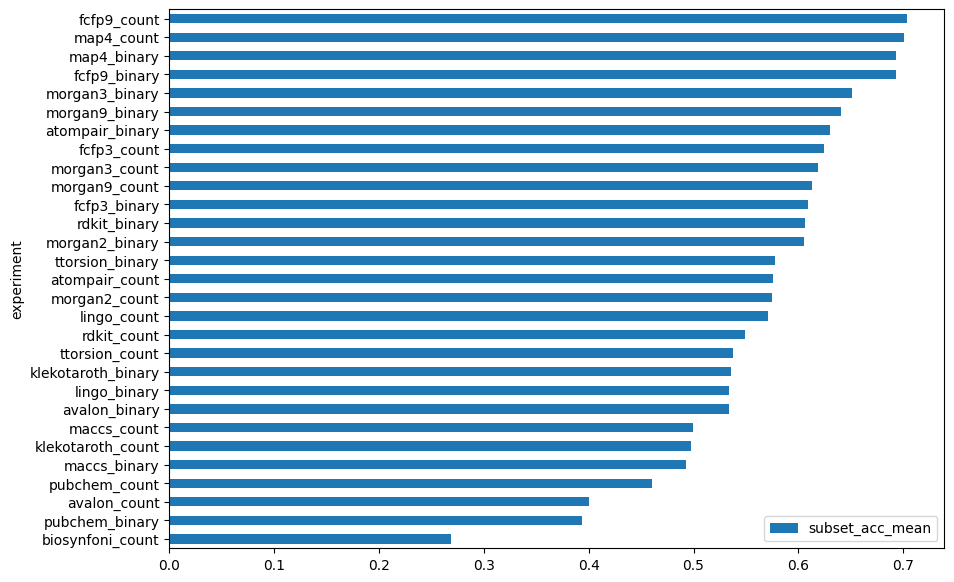

In [30]:
col_selected = "subset_acc_mean"

fig, ax = plt.subplots(figsize=(10,7))
selected_rows = [x for x in summary.experiment if "collapse_free" not in x]
summary.set_index("experiment").loc[selected_rows].sort_values(col_selected).plot(kind="barh", y=col_selected, ax=ax)

In [31]:
summary.columns

Index(['file', 'experiment', 'count_fp', 'input_dim', 'n_labels', 'n_splits',
       'macro_auc_mean', 'macro_auc_std', 'micro_auc_mean', 'micro_auc_std',
       'macro_f1_mean', 'macro_f1_std', 'micro_f1_mean', 'micro_f1_std',
       'weighted_f1_mean', 'weighted_f1_std', 'mean_label_acc_mean',
       'mean_label_acc_std', 'mean_label_bal_acc_mean',
       'mean_label_bal_acc_std', 'subset_acc_mean', 'subset_acc_std',
       'total_time_s', 'lr', 'batch_size', 'weight_decay', 'hidden_dim',
       'dropout'],
      dtype='object')

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_fingerprint_ranking(
    summary: pd.DataFrame,
    metric: str = "macro_auc_mean",
    top_n: int = 15,
    experiment_selection=None,
    figsize=(10, 7),
):
    """
    Plot top-N fingerprints by a chosen summary metric, with error bars if available.
    Returns (fig, ax).
    """
    if summary.empty:
        print("No summary data to plot.")
        return None, None

    std_col = metric.replace("_mean", "_std") if metric.endswith("_mean") else None

    df = _apply_experiment_selection(summary.copy(), experiment_selection)
    if df.empty:
        print("No experiments matched experiment_selection.")
        return None, None

    df = df.sort_values(metric, ascending=False).head(top_n).copy()

    x = np.arange(len(df))
    y = df[metric].values
    yerr = df[std_col].values if (std_col and std_col in df.columns) else None

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x, y, yerr=yerr)
    ax.set_xticks(x, df["experiment"].values, rotation=60, ha="right")
    ax.set_ylabel(metric)
    ax.set_title(f"Fingerprints by {metric}")

    return fig, ax


def _apply_experiment_selection(df: pd.DataFrame, experiment_selection):
    """
    experiment_selection can be:
      - None
      - list/tuple/set of experiment names (exact match)
      - callable: f(name:str)->bool applied to each experiment name
      - str: treated as substring filter (case-sensitive)
    """
    if experiment_selection is None:
        return df

    if callable(experiment_selection):
        mask = df["experiment"].astype(str).apply(experiment_selection)
        return df[mask]

    if isinstance(experiment_selection, str):
        return df[df["experiment"].astype(str).str.contains(experiment_selection, na=False)]

    if isinstance(experiment_selection, (list, tuple, set)):
        sel = list(map(str, experiment_selection))
        return df[df["experiment"].astype(str).isin(set(sel))]

    raise TypeError(
        "experiment_selection must be None, a callable, a string substring, or a list/tuple/set of names."
    )



In [33]:
per_label_all

,experiment,label,support_pos_mean,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,auc_roc_mean,auc_roc_std
0,atompair_binary_collapse_free,kinase_c,3.6,0.988433,0.011069,0.819350,0.120043,0.843294,0.151882
1,atompair_binary_collapse_free,antimalarial,17.6,0.962313,0.008068,0.798027,0.035909,0.885744,0.031569
2,atompair_binary_collapse_free,antibiotic,25.2,0.969403,0.006131,0.827694,0.055627,0.882184,0.034225
3,atompair_binary_collapse_free,phosphatase,17.8,0.964925,0.016125,0.806011,0.057935,0.866328,0.086506
4,atompair_binary_collapse_free,antifungal,72.2,0.891791,0.014330,0.779761,0.030890,0.859540,0.008827
...,...,...,...,...,...,...,...,...,...
583,ttorsion_count,leishmanial,3.2,0.983582,0.014415,0.839713,0.171220,0.877746,0.133534
584,ttorsion_count,serine_protease,5.6,0.997015,0.003869,0.982016,0.036582,0.996259,0.007076
585,ttorsion_count,hiv,37.4,0.892537,0.079533,0.779765,0.021105,0.827754,0.019985
586,ttorsion_count,antiviral,22.4,0.935448,0.038271,0.706765,0.023462,0.791911,0.038676


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_per_label_heatmap(
    per_label_all: pd.DataFrame,
    metric: str = "auc_roc_mean",
    top_n_fps: int = 12,
    experiment_selection=None,
    figsize=(12, 7),
    cmap=None,
    sort_labels: bool = True,
):
    """
    Simple heatmap: labels x fingerprints for a per-label metric.

    Steps:
      1) Filter per_label_all by experiment_selection using a mask on column 'experiment'
      2) Decide which experiments to show (top_n_fps by mean metric)
      3) Pivot to label x experiment and plot

    experiment_selection:
      - None: no filtering
      - str: substring match in experiment name
      - list/tuple/set: exact matches
      - callable: f(name)->bool
    Returns (fig, ax)
    """
    if per_label_all is None or per_label_all.empty:
        print("No per-label data to plot.")
        return None, None

    required = {"experiment", "label", metric}
    missing = required - set(per_label_all.columns)
    if missing:
        raise ValueError(f"per_label_all missing required columns: {sorted(missing)}")

    df = per_label_all.copy()
    exp = df["experiment"].astype(str)

    # 1) simple internal filtering mask
    if experiment_selection is None:
        mask = np.ones(len(df), dtype=bool)
    elif isinstance(experiment_selection, str):
        mask = exp.str.contains(experiment_selection, na=False).to_numpy()
    elif isinstance(experiment_selection, (list, tuple, set)):
        sel = set(map(str, experiment_selection))
        mask = exp.isin(sel).to_numpy()
    elif callable(experiment_selection):
        mask = exp.apply(experiment_selection).to_numpy()
    else:
        raise TypeError("experiment_selection must be None, str, list/tuple/set, or callable.")

    df = df.loc[mask].copy()
    if df.empty:
        print("No experiments matched experiment_selection.")
        return None, None

    # 2) choose experiments to display (top_n_fps by mean metric)
    exp_rank = (
        df.groupby("experiment")[metric]
          .mean()
          .sort_values(ascending=False)
          .index.astype(str)
          .tolist()
    )
    exp_keep = exp_rank[: min(top_n_fps, len(exp_rank))]

    df = df[df["experiment"].astype(str).isin(exp_keep)].copy()
    # 3) pivot to label x experiment (keep all labels present in df)
    pivot = df.pivot_table(index="label", columns="experiment", values=metric, aggfunc="mean")

    # enforce column order as exp_keep (in ranked order)
    pivot = pivot.reindex(columns=exp_keep)

    if sort_labels:
        pivot = pivot.sort_index(axis=0)

    data = pivot.to_numpy(dtype=float)

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="equal", cmap=cmap)
    fig.colorbar(im, ax=ax, label=metric)

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([str(c) for c in pivot.columns], rotation=60, ha="right")

    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels([str(r) for r in pivot.index])

    # keep full range visible (prevents edge clipping)
    ax.set_ylim(pivot.shape[0] - 0.5, -0.5)

    ax.set_title(f"Per-label {metric}")

    # draw cell borders
    ax.set_xticks(np.arange(-0.5, pivot.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, pivot.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
    
    # hide the minor tick marks/labels themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.tight_layout()
    return fig, ax


In [40]:
summary

,file,experiment,count_fp,input_dim,n_labels,n_splits,macro_auc_mean,macro_auc_std,micro_auc_mean,micro_auc_std,...,mean_label_bal_acc_mean,mean_label_bal_acc_std,subset_acc_mean,subset_acc_std,total_time_s,lr,batch_size,weight_decay,hidden_dim,dropout
0,fcfp3_count_collapse_free_mlp_multilabel_rando...,fcfp3_count_collapse_free,True,4096,12,5,0.888169,0.013268,0.887261,0.014032,...,0.822299,0.028234,0.539179,0.075045,11.609177,0.0030,256,0.000100,3000,0.2
1,morgan2_binary_mlp_multilabel_randomsplits_gri...,morgan2_binary,False,4096,12,5,0.886488,0.012867,0.889802,0.007030,...,0.812341,0.038806,0.605224,0.037140,11.636700,0.0030,256,0.000000,3000,0.2
2,map4_count_mlp_multilabel_randomsplits_gridtun...,map4_count,True,4096,12,5,0.884932,0.016124,0.896085,0.013703,...,0.778985,0.026314,0.700746,0.028435,15.035162,0.0003,128,0.000001,3000,0.2
3,atompair_binary_mlp_multilabel_randomsplits_gr...,atompair_binary,False,4096,12,5,0.884866,0.015920,0.901486,0.008210,...,0.805856,0.022992,0.630597,0.041863,18.180248,0.0010,256,0.000000,3000,0.2
4,morgan2_count_mlp_multilabel_randomsplits_grid...,morgan2_count,True,4096,12,5,0.884828,0.015657,0.892672,0.010651,...,0.804112,0.029628,0.575000,0.071524,11.880340,0.0030,256,0.000000,3000,0.2
5,map4_binary_mlp_multilabel_randomsplits_gridtu...,map4_binary,False,4096,12,5,0.884756,0.017129,0.897056,0.009100,...,0.775406,0.027693,0.693284,0.031124,14.986418,0.0003,128,0.000001,3000,0.2
6,fcfp3_binary_collapse_free_mlp_multilabel_rand...,fcfp3_binary_collapse_free,False,4096,12,5,0.884505,0.017678,0.884661,0.011513,...,0.816538,0.025025,0.571269,0.051642,12.109061,0.0030,256,0.000010,3000,0.2
7,fcfp9_binary_mlp_multilabel_randomsplits_gridt...,fcfp9_binary,False,4096,12,5,0.884410,0.016097,0.883659,0.006094,...,0.777216,0.028882,0.692910,0.022834,15.979751,0.0010,128,0.000000,3000,0.2
8,morgan2_count_collapse_free_mlp_multilabel_ran...,morgan2_count_collapse_free,True,4096,12,5,0.883350,0.012747,0.890527,0.012931,...,0.823043,0.026162,0.625373,0.027779,12.739967,0.0010,256,0.000010,3000,0.2
9,morgan2_binary_collapse_free_mlp_multilabel_ra...,morgan2_binary_collapse_free,False,4096,12,5,0.882919,0.014984,0.891687,0.013436,...,0.817544,0.033312,0.640672,0.021701,12.367695,0.0010,256,0.000010,3000,0.2


In [39]:
summary.experiment.unique()

array(['fcfp3_count_collapse_free', 'morgan2_binary', 'map4_count',
       'atompair_binary', 'morgan2_count', 'map4_binary',
       'fcfp3_binary_collapse_free', 'fcfp9_binary',
       'morgan2_count_collapse_free', 'morgan2_binary_collapse_free',
       'atompair_count', 'fcfp3_count', 'morgan3_binary', 'fcfp3_binary',
       'morgan3_count', 'fcfp9_count_collapse_free',
       'morgan3_count_collapse_free', 'fcfp9_binary_collapse_free',
       'fcfp9_count', 'morgan3_binary_collapse_free',
       'morgan9_count_collapse_free', 'morgan9_count',
       'atompair_count_collapse_free', 'morgan9_binary_collapse_free',
       'morgan9_binary', 'atompair_binary_collapse_free',
       'map4_count_collapse_free', 'rdkit_binary', 'maccs_count',
       'lingo_count_collapse_free', 'ttorsion_binary_collapse_free',
       'map4_binary_collapse_free', 'lingo_count', 'lingo_binary',
       'ttorsion_binary', 'avalon_binary', 'rdkit_count',
       'ttorsion_count_collapse_free', 'ttorsion_count', '

In [35]:
summary.columns

Index(['file', 'experiment', 'count_fp', 'input_dim', 'n_labels', 'n_splits',
       'macro_auc_mean', 'macro_auc_std', 'micro_auc_mean', 'micro_auc_std',
       'macro_f1_mean', 'macro_f1_std', 'micro_f1_mean', 'micro_f1_std',
       'weighted_f1_mean', 'weighted_f1_std', 'mean_label_acc_mean',
       'mean_label_acc_std', 'mean_label_bal_acc_mean',
       'mean_label_bal_acc_std', 'subset_acc_mean', 'subset_acc_std',
       'total_time_s', 'lr', 'batch_size', 'weight_decay', 'hidden_dim',
       'dropout'],
      dtype='object')

In [37]:
dones = []
select_best_of_each_type = []
for exp in summary.sort_values("weighted_f1_mean").experiment[::-1]:
    if exp.split("_")[0] not in dones:
        dones.append(exp.split("_")[0])
        select_best_of_each_type.append(exp)
select_best_of_each_type

['map4_count',
 'fcfp9_binary',
 'morgan2_binary_collapse_free',
 'morgan3_binary',
 'atompair_binary',
 'fcfp3_count',
 'rdkit_binary',
 'morgan9_binary',
 'ttorsion_binary',
 'avalon_binary',
 'lingo_count_collapse_free',
 'klekotaroth_binary',
 'maccs_count',
 'pubchem_count',
 'biosynfoni_count']

In [84]:
from chemap.plotting.colormaps import green_yellow_red

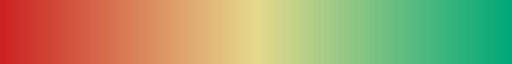

In [89]:
green_yellow_red.reversed()

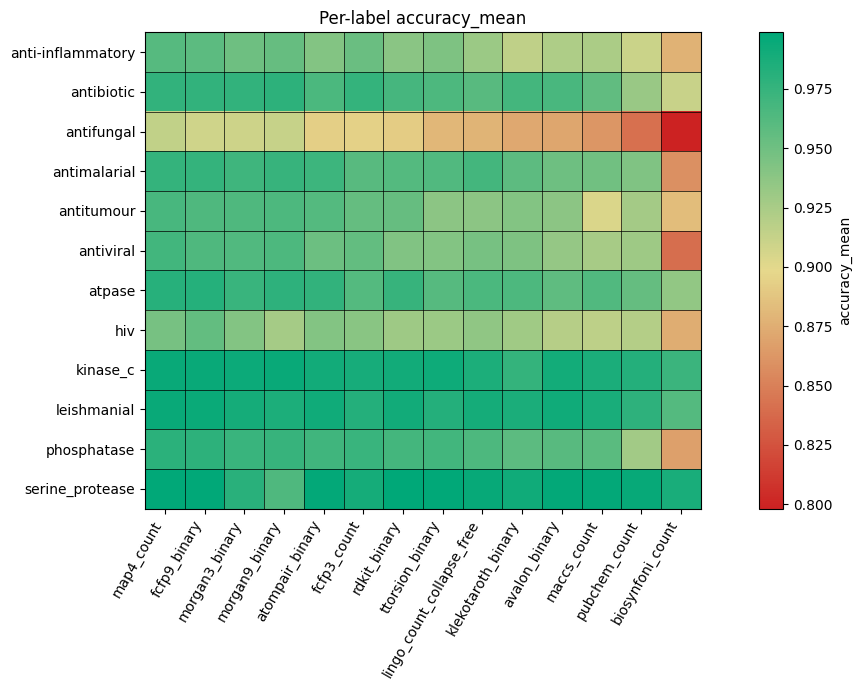

In [90]:
fig, ax = plot_per_label_heatmap(
    per_label_all, metric="accuracy_mean", top_n_fps=100,
    cmap=green_yellow_red.reversed(), #"winter",
    experiment_selection=[x for x in select_best_of_each_type if "morgan2" not in x])


plt.tight_layout()
plt.show()

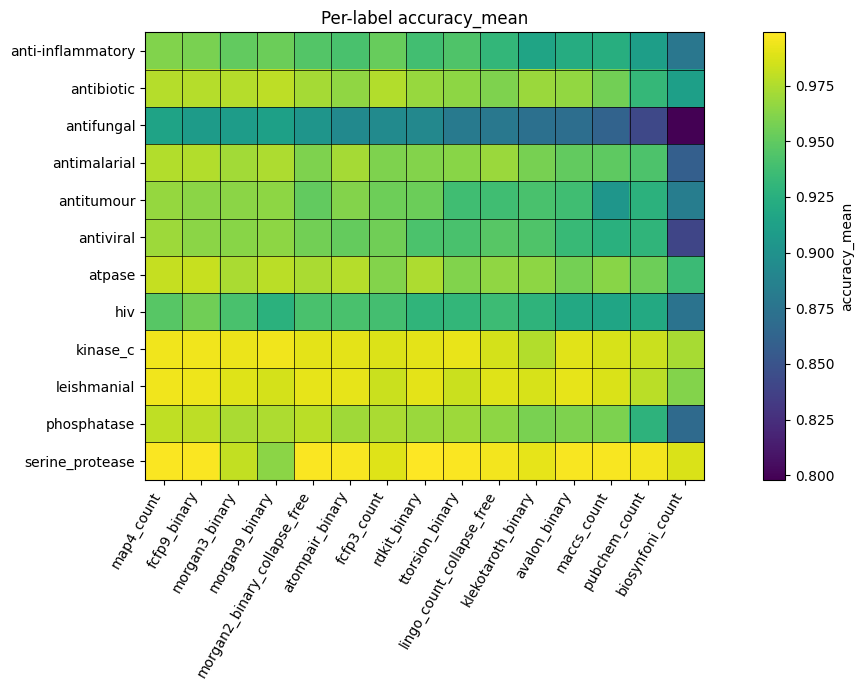

In [91]:
fig, ax = plot_per_label_heatmap(
    per_label_all, metric="accuracy_mean", top_n_fps=100,
    cmap="viridis", #"inferno",
    experiment_selection=select_best_of_each_type)#exp_select)
#plt.ylim(0.25)

plt.savefig("bioactivity_prediction_per_label_accuracy.png", dpi=400)
plt.tight_layout()
plt.show()

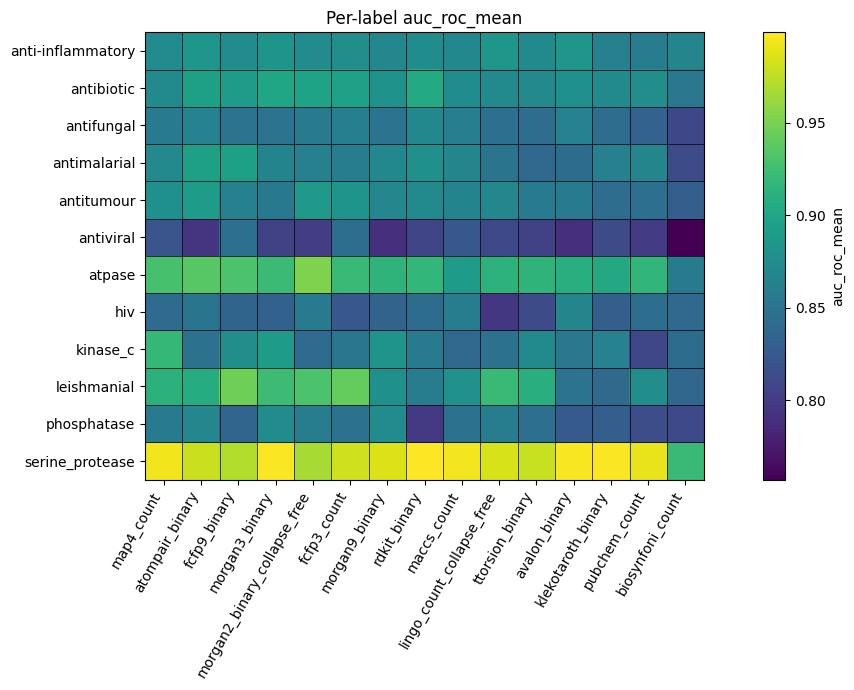

In [93]:
fig, ax = plot_per_label_heatmap(
    per_label_all, metric="auc_roc_mean", top_n_fps=100,
    cmap="viridis", #"inferno",
    experiment_selection=select_best_of_each_type)#exp_select)
#plt.ylim(0.25)

plt.savefig("bioactivity_prediction_per_label_auc_roc_mean.png", dpi=400)
plt.tight_layout()
plt.show()

In [ ]:
from chemap.plotting import cleveland_dotplot

In [41]:
from dataclasses import dataclass
from typing import Dict, Mapping, Optional, Sequence, Tuple
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.lines import Line2D


@dataclass(frozen=True)
class ClevelandStyle:
    """Styling defaults for a Cleveland-ish dot plot."""
    figsize: Tuple[float, float] = (9.0, 6.0)
    dpi: int = 600
    markersize: float = 7.0
    markeredgecolor: str = "white"
    connect_linestyle: str = ":"
    connect_linewidth: float = 2.0
    connect_alpha: float = 0.9
    grid_x_linestyle: str = ":"
    grid_y_linestyle: str = "-"
    grid_alpha_x: float = 0.6
    grid_alpha_y: float = 0.6


def cleveland_dotplot(
    *,
    # Data in "tidy" arrays
    row: Sequence[str],
    x: Sequence[float],
    color_group: Optional[Sequence[str]] = None,
    marker_group: Optional[Sequence[str]] = None,
    connect_group: Optional[Sequence[str]] = None,
    marker_zorder: Optional[Mapping[str, float]] = None,

    # Ordering / labels
    row_order: Optional[Sequence[str]] = None,
    row_label_fn=None,

    # Mappings
    color_map: Optional[Dict[str, str]] = None,
    marker_map: Optional[Dict[str, str]] = None,

    # Figure/axes
    title: str = "",
    xlabel: str = "",
    ax: Optional[Axes] = None,

    # Behavior
    connect: bool = True,
    show_zero_line_if_needed: bool = True,

    # Range line
    row_range: bool = True,
    row_range_color: str = "black",
    row_range_linewidth: float = 1.5,
    row_range_alpha: float = 0.75,

    # Legends
    show_legends: bool = True,
    color_legend_title: str = "Setting",
    marker_legend_title: str = "Variant",

    style: ClevelandStyle = ClevelandStyle(),
) -> Tuple[Figure, Axes]:
    """
    Generic Cleveland-ish dot plot.

    Parameters
    ----------
    row, x
        One entry per point. `row` defines which horizontal row the point belongs to,
        `x` is the numeric x-position.
    color_group
        Category that controls dot color (e.g., binary/count/logcount).
    marker_group
        Category that controls marker shape (e.g., dense/sparse/fixed).
    connect_group
        Group id used to connect points on the same row (e.g., same setting).
        Connection happens within (row, connect_group).
    connect
        If True, draw a line between min(x) and max(x) within each (row, connect_group).
    """

    # --- normalize inputs ---
    row = list(map(str, row))
    x = np.asarray(x, dtype=float)

    n = len(row)
    if x.shape[0] != n:
        raise ValueError("row and x must have the same length")

    if color_group is None:
        color_group = ["_"] * n
    else:
        color_group = list(map(str, color_group))
        if len(color_group) != n:
            raise ValueError("color_group must match length of row/x")

    if marker_group is None:
        marker_group = ["_"] * n
    else:
        marker_group = list(map(str, marker_group))
        if len(marker_group) != n:
            raise ValueError("marker_group must match length of row/x")

    if connect_group is None:
        connect_group = ["_"] * n
    else:
        connect_group = list(map(str, connect_group))
        if len(connect_group) != n:
            raise ValueError("connect_group must match length of row/x")

    # Default mappings
    if color_map is None:
        # Let matplotlib handle if not provided: we’ll still create a legend if asked.
        color_map = {}

    if marker_map is None:
        marker_map = {"_": "o"}  # default to circle

    if marker_zorder is None:
        marker_zorder = {}

    # Row order
    if row_order is None:
        # stable order by appearance
        seen = []
        seen_set = set()
        for r in row:
            if r not in seen_set:
                seen.append(r)
                seen_set.add(r)
        row_order = seen
    else:
        row_order = list(map(str, row_order))

    ypos = {r: i for i, r in enumerate(row_order)}
    y = np.array([ypos[r] for r in row], dtype=float)

    # Labels
    if row_label_fn is None:
        row_label_fn = lambda s: s  # noqa: E731

    # --- axes setup ---
    if ax is None:
        fig_h = max(2.5, len(row_order) * 0.28)
        fig, ax = plt.subplots(figsize=(style.figsize[0], fig_h), dpi=style.dpi)
    else:
        fig = ax.figure

    # Row-range indicator (min->max across ALL points in the row)
    if row_range:
        from collections import defaultdict
        xs_by_row = defaultdict(list)
        for r, xv in zip(row, x):
            xs_by_row[r].append(float(xv))

        for r in row_order:
            xs = xs_by_row.get(r, [])
            if len(xs) < 2:
                continue
            y0 = ypos[r]
            ax.plot(
                [min(xs), max(xs)],
                [y0, y0],
                color=row_range_color,
                linewidth=row_range_linewidth,
                alpha=row_range_alpha,
                zorder=0,  # behind connectors + points
            )

    # --- optional connectors ---
    if connect:
        # For each (row, connect_group), connect min->max x
        key_arr = list(zip(row, connect_group))
        # group indices by key
        from collections import defaultdict
        idx_by_key = defaultdict(list)
        for i, k in enumerate(key_arr):
            idx_by_key[k].append(i)

        for (r, cg), idxs in idx_by_key.items():
            if len(idxs) < 2:
                continue
            xs = x[idxs]
            y0 = ypos[r]
            col_key = color_group[idxs[0]]
            col = color_map.get(col_key, "gray")
            ax.plot(
                [float(xs.min()), float(xs.max())],
                [y0, y0],
                linestyle=style.connect_linestyle,
                linewidth=style.connect_linewidth,
                alpha=style.connect_alpha,
                color=col,
                zorder=1,
            )

    # --- plot dots ---
    # Plot by (marker_group, color_group) so style is consistent & legend-friendly
    uniq_marker = list(dict.fromkeys(marker_group))
    uniq_color = list(dict.fromkeys(color_group))

    for mg in uniq_marker:
        m = marker_map.get(mg, "o")
        z = float(marker_zorder.get(mg, 3.0))
        for cg in uniq_color:
            mask = [(marker_group[i] == mg and color_group[i] == cg) for i in range(n)]
            if not any(mask):
                continue
            xs = x[mask]
            ys = y[mask]
            col = color_map.get(cg, None)
            ax.plot(
                xs, ys,
                linestyle="None",
                marker=m,
                color=col,
                markersize=style.markersize,
                markeredgecolor=style.markeredgecolor,
                zorder=z,
                label=None,  # legends are handled manually
            )

    # zero line if needed
    if show_zero_line_if_needed and n > 0 and float(np.min(x)) <= 0.0:
        ax.axvline(0, linestyle="--", linewidth=1.5, color="black")

    # axes / labels
    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels([row_label_fn(r) for r in row_order])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle=style.grid_x_linestyle, alpha=style.grid_alpha_x)
    ax.grid(True, axis="y", linestyle=style.grid_y_linestyle, alpha=style.grid_alpha_y)
    ax.set_axisbelow(True)

    # --- legends ---
    if show_legends:
        # marker legend
        marker_handles = []
        for mg in uniq_marker:
            if mg == "_" and len(set(uniq_marker)) == 1:
                continue
            marker_handles.append(
                Line2D([0], [0], marker=marker_map.get(mg, "o"),
                       color="black", linestyle="None", label=str(mg))
            )

        # color legend
        color_handles = []
        for cg in uniq_color:
            if cg == "_" and len(set(uniq_color)) == 1:
                continue
            col = color_map.get(cg, "gray")
            color_handles.append(
                Line2D([0], [0], marker="o", color=col, linestyle="None", label=str(cg))
            )

        # Place legends similarly to your original if both exist
        if marker_handles and color_handles:
            leg1 = ax.legend(handles=marker_handles, loc="lower right",
                             title=marker_legend_title, frameon=True)
            ax.add_artist(leg1)
            ax.legend(handles=color_handles, loc="lower left",
                      title=color_legend_title, frameon=True)
        elif marker_handles:
            ax.legend(handles=marker_handles, loc="lower right",
                      title=marker_legend_title, frameon=True)
        elif color_handles:
            ax.legend(handles=color_handles, loc="lower left",
                      title=color_legend_title, frameon=True)

    return fig, ax

In [44]:
summary_df = summary.copy()

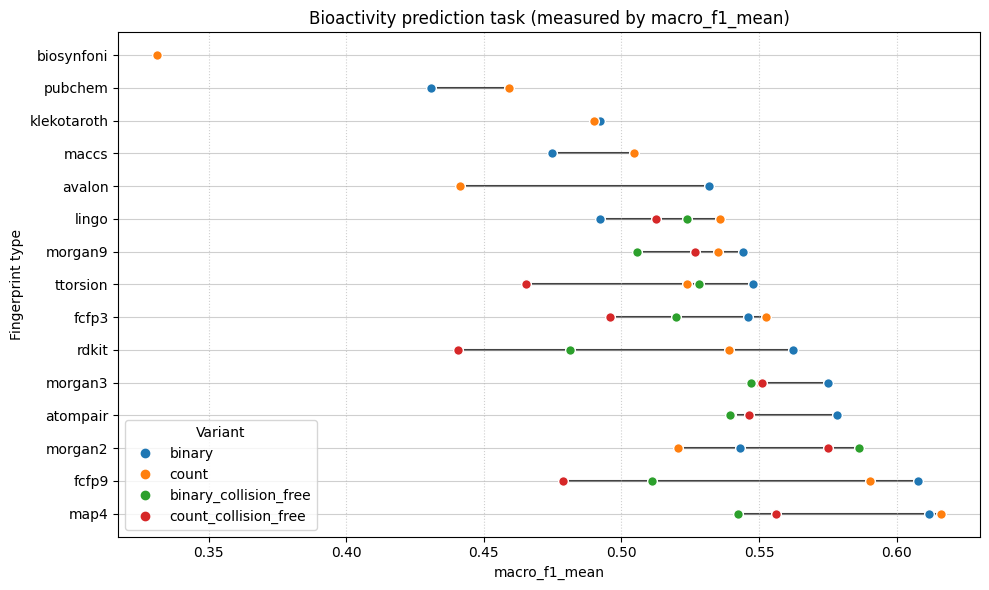

In [77]:
import re
import pandas as pd
import matplotlib.pyplot as plt


col_select = "macro_f1_mean"


def split_fp_and_variant(exp_name: str):
    s = str(exp_name)

    # fingerprint_type = first chunk (everything before first "_binary"/"_count" token)
    # mode detection
    if re.search(r"(^|_)count($|_)", s):
        mode = "count"
    elif re.search(r"(^|_)binary($|_)", s):
        mode = "binary"
    else:
        mode = "other"

    # extra tag(s)
    extra = []
    if re.search(r"(^|_)collapse_free($|_)", s):
        extra.append("collision_free")  # ✅ rename here

    # base type: remove known variant tokens
    base = s
    base = re.sub(r"(^|_)count($|_)", "_", base)
    base = re.sub(r"(^|_)binary($|_)", "_", base)
    base = re.sub(r"(^|_)collapse_free($|_)", "_", base)
    base = re.sub(r"__+", "_", base).strip("_")

    # variant label
    if mode in ("count", "binary"):
        variant = mode
    else:
        variant = "default"
    if extra:
        variant = variant + "_" + "_".join(extra)

    return base, variant


# ---- Build plotting table ----
summary_df[["fingerprint_type", "variant"]] = summary_df["experiment"].apply(
    lambda x: pd.Series(split_fp_and_variant(x))
)

plot_df = summary_df[["fingerprint_type", "variant", col_select]].copy()
plot_df = plot_df.dropna(subset=["fingerprint_type", "variant", col_select])

# Row order by best AUC per fingerprint type (ascending because we invert y)
order = (
    plot_df.groupby("fingerprint_type")[col_select]
    .max()
    .sort_values(ascending=True)
    .index
    .tolist()
)

# Stable ordering for variants (with collision_free)
variant_order = [
    "binary",
    "count",
    "binary_collision_free",
    "count_collision_free",
    "default",
]
plot_df["variant"] = pd.Categorical(plot_df["variant"], categories=variant_order, ordered=True)
plot_df = plot_df.sort_values(["fingerprint_type", "variant"])

# Stable colors (only for variants actually present)
cmap = plt.get_cmap("tab10")
present_variants = [v for v in variant_order if v in set(plot_df["variant"].dropna().astype(str))]
variant_color = {v: cmap(i % 10) for i, v in enumerate(present_variants)}

# ---- Plot ----
fig_h = max(6, 0.35 * len(order))
fig, ax = plt.subplots(figsize=(10, fig_h))

fig, ax = cleveland_dotplot(
    row=plot_df["fingerprint_type"].astype(str).tolist(),
    x=plot_df[col_select].to_numpy(dtype=float),
    color_group=plot_df["variant"].astype(str).tolist(),
    marker_group=None,              # single marker; legend shows colors (variants)
    connect=False,                  # not needed here
    row_range=True,                 # ✅ min-max guide line per fingerprint type
    row_order=order,
    ax=ax,
    xlabel=col_select,
    title=f"Bioactivity prediction task (measured by {col_select})",
    color_map=variant_color,
    color_legend_title="Variant",
    show_zero_line_if_needed=False,
)

ax.set_ylabel("Fingerprint type")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"bioactivtiy_prediction_task_{col_select}.png", dpi=400)
plt.show()


In [47]:
summary.columns

Index(['file', 'experiment', 'count_fp', 'input_dim', 'n_labels', 'n_splits',
       'macro_auc_mean', 'macro_auc_std', 'micro_auc_mean', 'micro_auc_std',
       'macro_f1_mean', 'macro_f1_std', 'micro_f1_mean', 'micro_f1_std',
       'weighted_f1_mean', 'weighted_f1_std', 'mean_label_acc_mean',
       'mean_label_acc_std', 'mean_label_bal_acc_mean',
       'mean_label_bal_acc_std', 'subset_acc_mean', 'subset_acc_std',
       'total_time_s', 'lr', 'batch_size', 'weight_decay', 'hidden_dim',
       'dropout'],
      dtype='object')

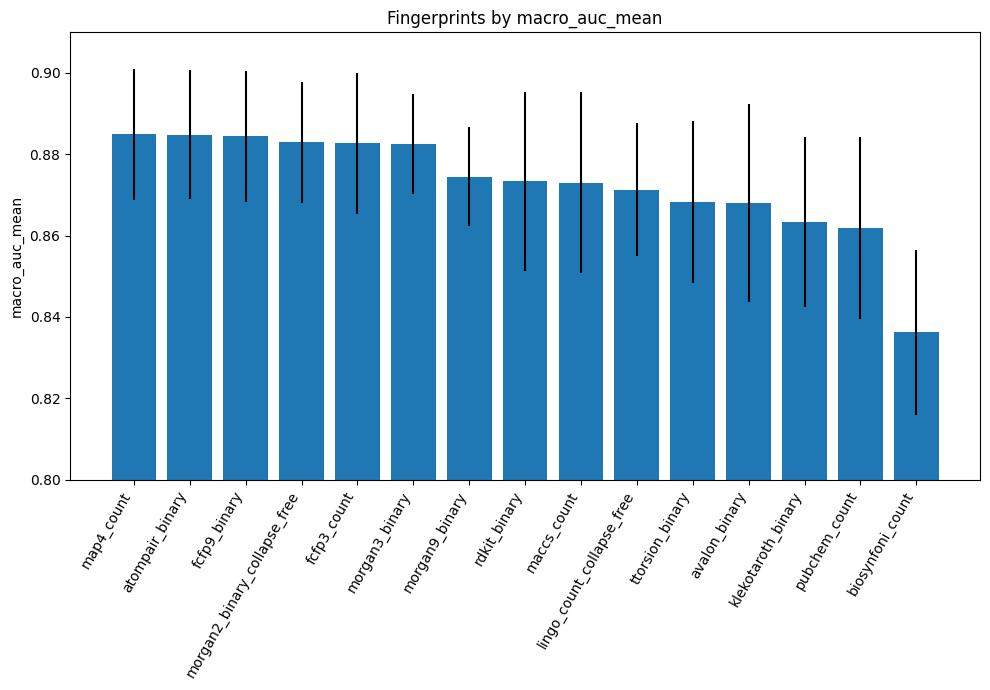

In [52]:
fig, ax = plot_fingerprint_ranking(
    summary, metric="macro_auc_mean", top_n=100,
    experiment_selection=select_best_of_each_type)#exp_select)
plt.ylim(0.8, 0.91)
plt.tight_layout()
plt.show()

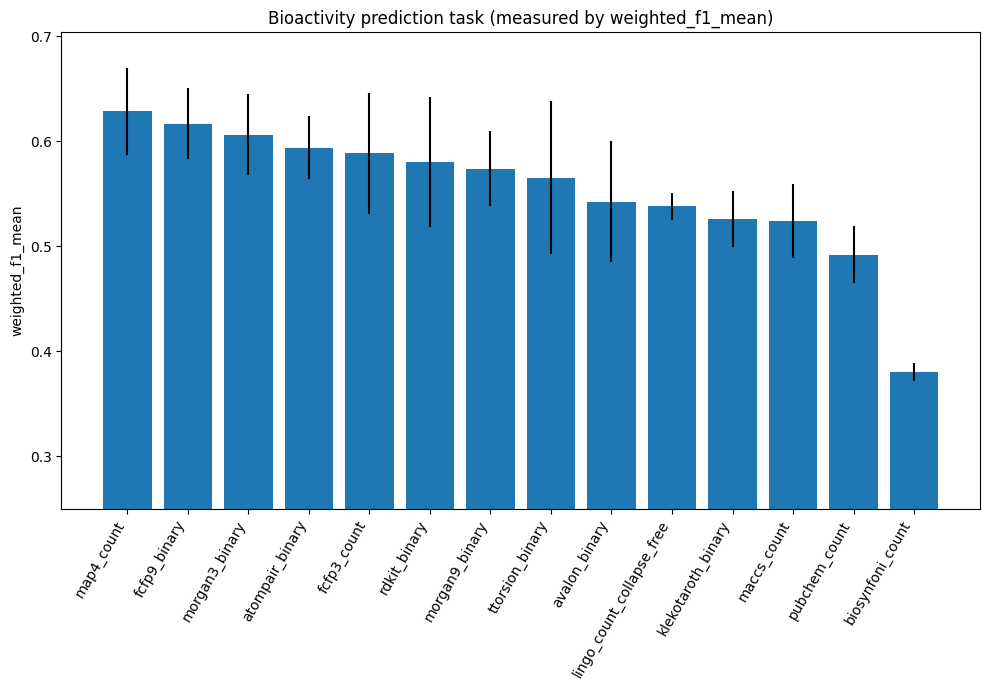

In [64]:
# Plot: ranking of fingerprints (with std error bars)
#exp_select = [x for x in summary.experiment if "collapse" not in x]

col_select = "weighted_f1_mean"

fig, ax = plot_fingerprint_ranking(
    summary, metric=col_select, top_n=100,
    experiment_selection=[x for x in select_best_of_each_type if "morgan2" not in x])
plt.ylim(0.25)
plt.title(f"Bioactivity prediction task (measured by {col_select})")
plt.tight_layout()
plt.savefig(f"bioactivtiy_prediction_task_{col_select}_barplot.png", dpi=400)
plt.show()


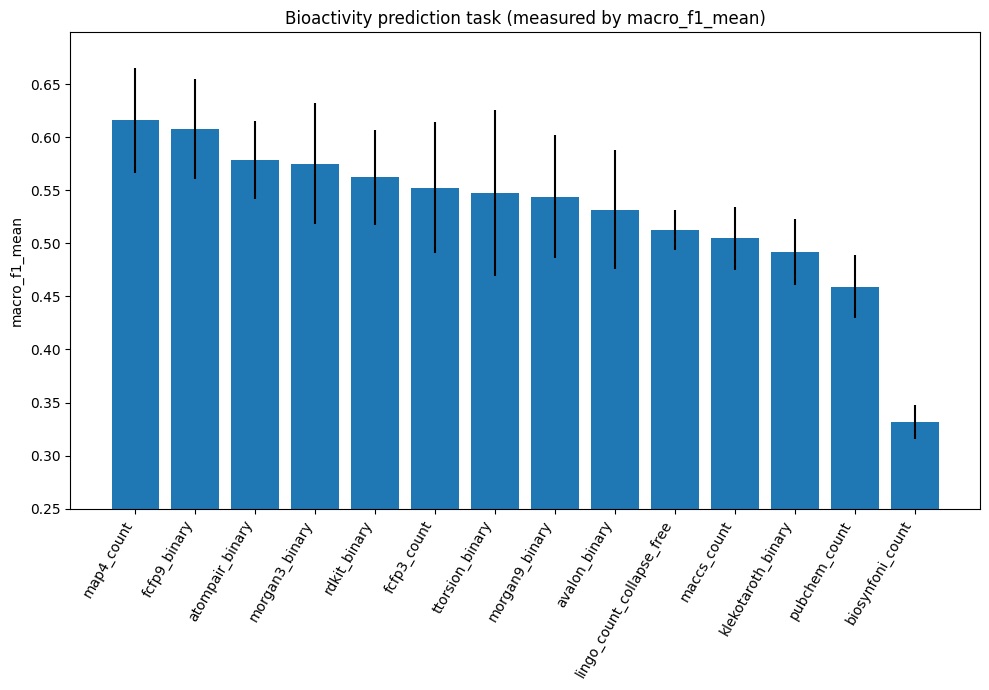

In [76]:
col_select = "macro_f1_mean"

fig, ax = plot_fingerprint_ranking(
    summary, metric=col_select, top_n=100,
    experiment_selection=[x for x in select_best_of_each_type if "morgan2" not in x])
plt.ylim(0.25)
plt.title(f"Bioactivity prediction task (measured by {col_select})")
plt.tight_layout()
plt.savefig(f"bioactivtiy_prediction_task_{col_select}_barplot.png", dpi=400)
plt.show()

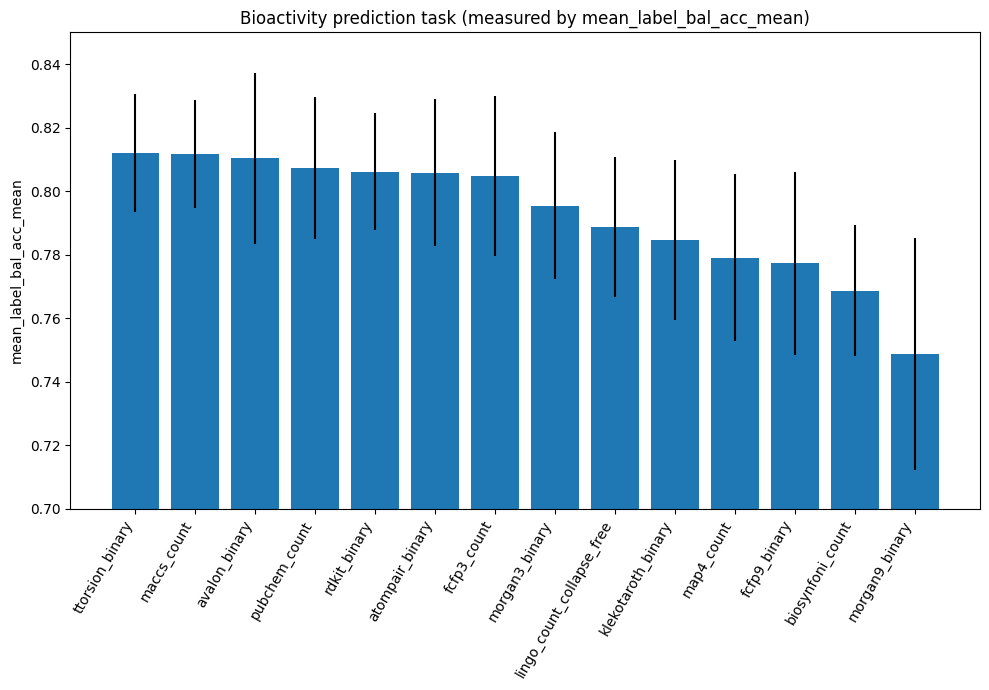

In [70]:
# Plot: ranking of fingerprints (with std error bars)
#exp_select = [x for x in summary.experiment if "collapse" not in x]

col_select = "mean_label_bal_acc_mean"

fig, ax = plot_fingerprint_ranking(
    summary, metric=col_select, top_n=100,
    experiment_selection=[x for x in select_best_of_each_type if "morgan2" not in x])
plt.ylim(0.7, 0.85)
plt.title(f"Bioactivity prediction task (measured by {col_select})")
plt.tight_layout()
plt.savefig(f"bioactivtiy_prediction_task_{col_select}_barplot.png", dpi=400)
plt.show()


In [123]:
summary.columns

Index(['file', 'experiment', 'count_fp', 'input_dim', 'n_labels', 'n_splits',
       'macro_auc_mean', 'macro_auc_std', 'micro_auc_mean', 'micro_auc_std',
       'macro_f1_mean', 'macro_f1_std', 'micro_f1_mean', 'micro_f1_std',
       'weighted_f1_mean', 'weighted_f1_std', 'mean_label_acc_mean',
       'mean_label_acc_std', 'mean_label_bal_acc_mean',
       'mean_label_bal_acc_std', 'subset_acc_mean', 'subset_acc_std',
       'total_time_s', 'lr', 'batch_size', 'weight_decay', 'hidden_dim',
       'dropout'],
      dtype='object')

In [58]:
select_best_of_each_type

['map4_count',
 'fcfp9_binary',
 'morgan2_binary_collapse_free',
 'morgan3_binary',
 'atompair_binary',
 'fcfp3_count',
 'rdkit_binary',
 'morgan9_binary',
 'ttorsion_binary',
 'avalon_binary',
 'lingo_count_collapse_free',
 'klekotaroth_binary',
 'maccs_count',
 'pubchem_count',
 'biosynfoni_count']

In [59]:
[x for x in select_best_of_each_type if "morgan2" not in x]

['map4_count',
 'fcfp9_binary',
 'morgan3_binary',
 'atompair_binary',
 'fcfp3_count',
 'rdkit_binary',
 'morgan9_binary',
 'ttorsion_binary',
 'avalon_binary',
 'lingo_count_collapse_free',
 'klekotaroth_binary',
 'maccs_count',
 'pubchem_count',
 'biosynfoni_count']

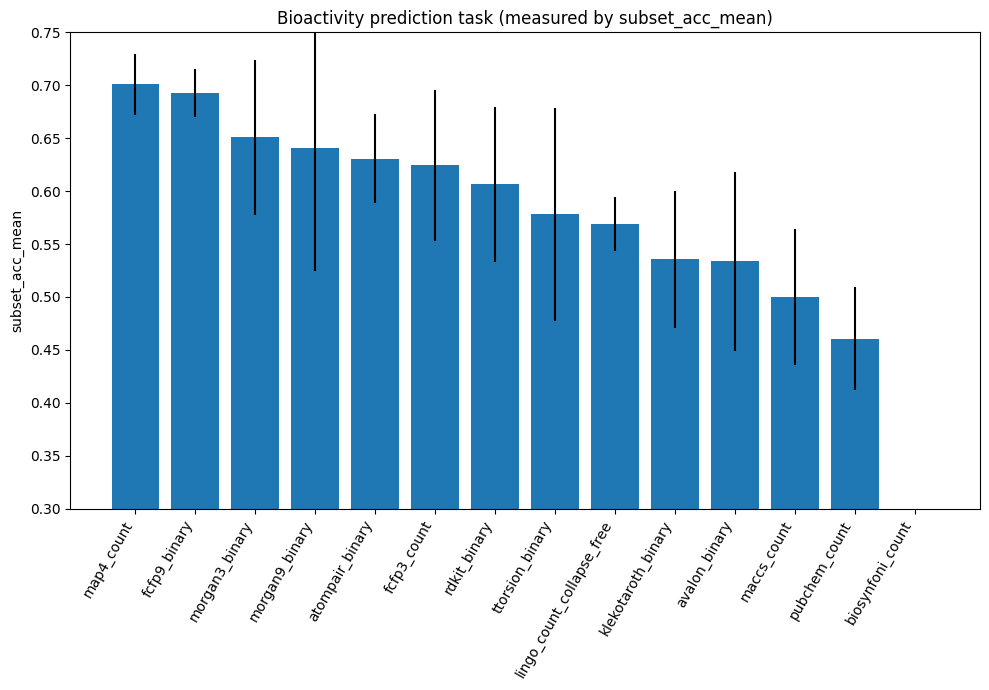

In [75]:
col_select = "subset_acc_mean"

fig, ax = plot_fingerprint_ranking(
    summary, metric=col_select, top_n=100,
    experiment_selection=[x for x in select_best_of_each_type if "morgan2" not in x])
plt.ylim(0.3, 0.75)
plt.title(f"Bioactivity prediction task (measured by {col_select})")
plt.tight_layout()
plt.savefig(f"bioactivtiy_prediction_task_{col_select}_barplot.png", dpi=400)
plt.show()


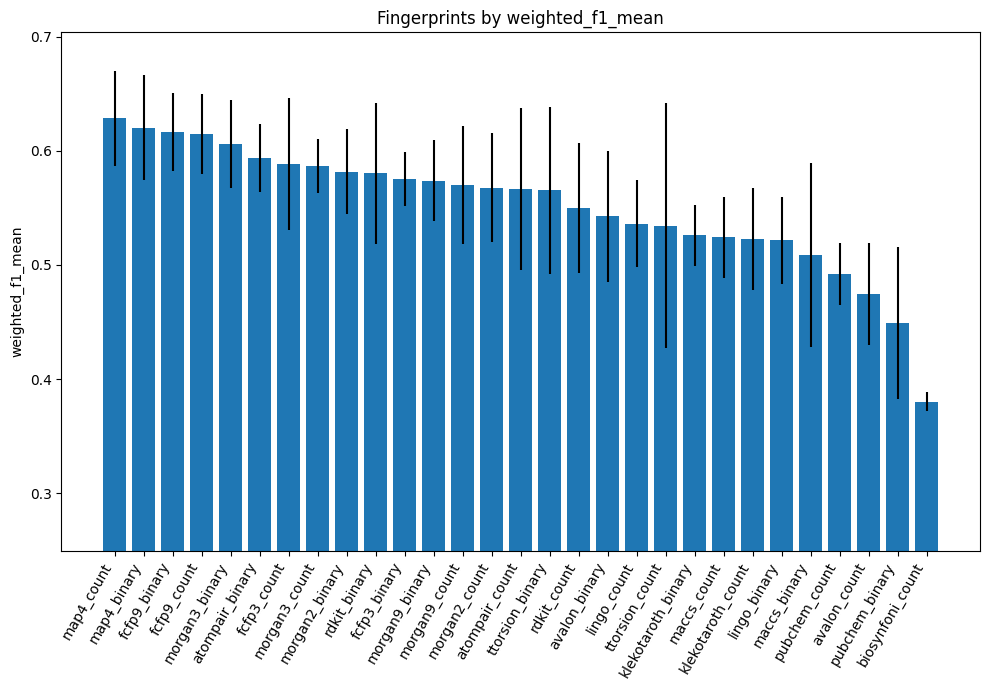

In [122]:
# Plot: ranking of fingerprints (with std error bars)
exp_select = [x for x in summary.experiment if "collapse" not in x]

fig, ax = plot_fingerprint_ranking(
    summary, metric="weighted_f1_mean", top_n=100,
    experiment_selection=exp_select)
plt.ylim(0.25)
plt.tight_layout()
plt.show()


In [127]:
summary

,file,experiment,count_fp,input_dim,n_labels,n_splits,macro_auc_mean,macro_auc_std,micro_auc_mean,micro_auc_std,...,mean_label_bal_acc_mean,mean_label_bal_acc_std,subset_acc_mean,subset_acc_std,total_time_s,lr,batch_size,weight_decay,hidden_dim,dropout
0,fcfp3_count_collapse_free_mlp_multilabel_rando...,fcfp3_count_collapse_free,True,4096,12,5,0.888169,0.013268,0.887261,0.014032,...,0.822299,0.028234,0.539179,0.075045,11.609177,0.0030,256,0.000100,3000,0.2
1,morgan2_binary_mlp_multilabel_randomsplits_gri...,morgan2_binary,False,4096,12,5,0.886488,0.012867,0.889802,0.007030,...,0.812341,0.038806,0.605224,0.037140,11.636700,0.0030,256,0.000000,3000,0.2
2,map4_count_mlp_multilabel_randomsplits_gridtun...,map4_count,True,4096,12,5,0.884932,0.016124,0.896085,0.013703,...,0.778985,0.026314,0.700746,0.028435,15.035162,0.0003,128,0.000001,3000,0.2
3,atompair_binary_mlp_multilabel_randomsplits_gr...,atompair_binary,False,4096,12,5,0.884866,0.015920,0.901486,0.008210,...,0.805856,0.022992,0.630597,0.041863,18.180248,0.0010,256,0.000000,3000,0.2
4,morgan2_count_mlp_multilabel_randomsplits_grid...,morgan2_count,True,4096,12,5,0.884828,0.015657,0.892672,0.010651,...,0.804112,0.029628,0.575000,0.071524,11.880340,0.0030,256,0.000000,3000,0.2
5,map4_binary_mlp_multilabel_randomsplits_gridtu...,map4_binary,False,4096,12,5,0.884756,0.017129,0.897056,0.009100,...,0.775406,0.027693,0.693284,0.031124,14.986418,0.0003,128,0.000001,3000,0.2
6,fcfp3_binary_collapse_free_mlp_multilabel_rand...,fcfp3_binary_collapse_free,False,4096,12,5,0.884505,0.017678,0.884661,0.011513,...,0.816538,0.025025,0.571269,0.051642,12.109061,0.0030,256,0.000010,3000,0.2
7,fcfp9_binary_mlp_multilabel_randomsplits_gridt...,fcfp9_binary,False,4096,12,5,0.884410,0.016097,0.883659,0.006094,...,0.777216,0.028882,0.692910,0.022834,15.979751,0.0010,128,0.000000,3000,0.2
8,morgan2_count_collapse_free_mlp_multilabel_ran...,morgan2_count_collapse_free,True,4096,12,5,0.883350,0.012747,0.890527,0.012931,...,0.823043,0.026162,0.625373,0.027779,12.739967,0.0010,256,0.000010,3000,0.2
9,morgan2_binary_collapse_free_mlp_multilabel_ra...,morgan2_binary_collapse_free,False,4096,12,5,0.882919,0.014984,0.891687,0.013436,...,0.817544,0.033312,0.640672,0.021701,12.367695,0.0010,256,0.000010,3000,0.2
